### Data Cleaning and Processing

In [127]:
#Loading the required packages

import pandas as pd
import matplotlib as pyplot 
import seaborn as sn


In [128]:
#loading the data
Rental = pd.read_csv("/Users/nyadual/Desktop/Canada_Cost_of_Living/Rental_Prices_databaseLoadingData.csv")
Rental.head()

,REF_DATE,GEO,DGUID,Rental unit type,Estimates,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,Jan-20,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,810.0,NaN,NaN,NaN,0
1,Apr-20,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,860.0,NaN,NaN,NaN,0
2,Jul-20,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,860.0,NaN,NaN,NaN,0
3,Oct-20,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,850.0,NaN,NaN,NaN,0
4,Jan-21,"St. John's, Census metropolitan area (CMA)",2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,870.0,NaN,NaN,NaN,0


In [129]:
#cleaning the rental data
#remove CMA in the GEO column

Rental["GEO"] = Rental["GEO"].str.replace(",.*", "", regex=True).str.strip()
Rental.head()

,REF_DATE,GEO,DGUID,Rental unit type,Estimates,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,Jan-20,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,810.0,NaN,NaN,NaN,0
1,Apr-20,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,860.0,NaN,NaN,NaN,0
2,Jul-20,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,860.0,NaN,NaN,NaN,0
3,Oct-20,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,850.0,NaN,NaN,NaN,0
4,Jan-21,St. John's,2021S0503001,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1675424962,1.2.1,870.0,NaN,NaN,NaN,0


In [130]:
#remove the unwanted columns
Rental = Rental[["REF_DATE", "GEO", "Rental unit type", "Estimates", "VALUE"]]

#Change columns name
Rental = Rental.rename(columns = {"VALUE": "Rental_value"})

# Convert date
Rental["REF_DATE"] = pd.to_datetime(Rental["REF_DATE"], format="%b-%y")
Rental["Year"] = Rental["REF_DATE"].dt.year
Rental["Quarter"] = Rental["REF_DATE"].dt.quarter

Rental.head()

,REF_DATE,GEO,Rental unit type,Estimates,Rental_value,Year,Quarter
0,2020-01-01,St. John's,Apartment - 1 bedroom,Average asking rent,810.0,2020,1
1,2020-04-01,St. John's,Apartment - 1 bedroom,Average asking rent,860.0,2020,2
2,2020-07-01,St. John's,Apartment - 1 bedroom,Average asking rent,860.0,2020,3
3,2020-10-01,St. John's,Apartment - 1 bedroom,Average asking rent,850.0,2020,4
4,2021-01-01,St. John's,Apartment - 1 bedroom,Average asking rent,870.0,2021,1


In [131]:
#Pvoting Rental data

Rental = Rental[Rental["Rental unit type"].isin([
    "Apartment - 1 bedroom",
    "Apartment - 2 bedrooms",
    "Apartment - 3 bedrooms"  # include only if it exists
])]

Rental_pivot = Rental.pivot_table(
    index=["GEO", "Year", "Quarter"],
    columns="Rental unit type",
    values="Rental_value",
    aggfunc="mean"
).reset_index()

#renaming columns
Rental_pivot = Rental_pivot.rename(columns={
    "Apartment - 1 bedroom": "1_Bedroom_Rent",
    "Apartment - 2 bedrooms": "2_Bedroom_Rent",

})

#renaming  GEO to City
Rental_pivot = Rental_pivot.rename(columns={"GEO": "City"})

Rental_pivot.head()

Rental unit type,City,Year,Quarter,1_Bedroom_Rent,2_Bedroom_Rent
0,Abbotsford - Mission,2020,1,1120.0,1330.0
1,Abbotsford - Mission,2020,2,1120.0,1380.0
2,Abbotsford - Mission,2020,3,1120.0,1370.0
3,Abbotsford - Mission,2020,4,1190.0,1340.0
4,Abbotsford - Mission,2021,1,1200.0,1580.0


In [134]:
#Loading CPI data

CPI = pd.read_csv("/Users/nyadual/Desktop/Canada_Cost_of_Living/Consumer_Price-Index_databaseLoadingData.csv")
CPI.head()

,REF_DATE,GEO,DGUID,Products and product groups,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,Jan-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,140.0,NaN,NaN,NaN,1
1,Feb-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,140.3,NaN,NaN,NaN,1
2,Mar-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,139.2,NaN,NaN,NaN,1
3,Apr-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,137.6,NaN,NaN,NaN,1
4,May-20,Newfoundland and Labrador,2016A000210,All-items,2002=100,17,units,0,v41691244,3.2,138.2,NaN,NaN,NaN,1


In [135]:
#Cleaning CPI data

#Droping the unwanted columns and keeping the wanted
CPI = CPI[["REF_DATE", "GEO", "Products and product groups", "VALUE"]]

#Renaming the columns
CPI = CPI.rename(columns={"VALUE": "CPI_Value"})

# Convert date
CPI["REF_DATE"] = pd.to_datetime(CPI["REF_DATE"],format="%b-%y")

CPI["Year"] = CPI["REF_DATE"].dt.year
CPI["Quarter"] = CPI["REF_DATE"].dt.quarter

# Clean GEO
CPI["GEO"] = CPI["GEO"].str.replace(",.*", "", regex=True).str.strip()

CPI.head()


,REF_DATE,GEO,Products and product groups,CPI_Value,Year,Quarter
0,2020-01-01,Newfoundland and Labrador,All-items,140.0,2020,1
1,2020-02-01,Newfoundland and Labrador,All-items,140.3,2020,1
2,2020-03-01,Newfoundland and Labrador,All-items,139.2,2020,1
3,2020-04-01,Newfoundland and Labrador,All-items,137.6,2020,2
4,2020-05-01,Newfoundland and Labrador,All-items,138.2,2020,2


In [136]:
#pivoting CPI data

CPI_pivot = CPI.pivot_table(
    index=["GEO", "Year", "Quarter"],
    columns="Products and product groups",
    values="CPI_Value",
    aggfunc="mean"
).reset_index()

#renaming columns
CPI_pivot = CPI_pivot.rename(columns={
    "GEO": "province",
    "Household operations, furnishings and equipment": "Household_ops"
})

#dropping unwanted columns (if present)
CPI_pivot = CPI_pivot.drop(columns=["All-items excluding energy", "All-items excluding food and energy"], errors='ignore')

#Rearranging columns — use reindex to avoid KeyError if a column is missing
desired_cols = [
    "province",
    "Year",
    "Quarter",
    "All-items",
    "Food",
    "Shelter",
    "Household_ops",
    "Clothing and footwear",
    "Transportation",
    "Health and personal care",
    "Recreation, education and reading",
    "Alcoholic beverages, tobacco products and recreational cannabis"
]

CPI_pivot = CPI_pivot.reindex(columns=desired_cols)

CPI_pivot.head()

Products and product groups,province,Year,Quarter,All-items,Food,Shelter,Household_ops,Clothing and footwear,Transportation,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis"
0,Alberta,2020,1,144.766667,153.200000,174.466667,122.566667,102.000000,146.133333,139.766667,114.633333,171.466667
1,Alberta,2020,2,144.033333,153.700000,173.733333,122.633333,96.666667,144.700000,139.500000,114.666667,173.400000
2,Alberta,2020,3,144.700000,152.800000,174.666667,122.666667,96.933333,147.233333,140.233333,115.466667,172.266667
3,Alberta,2020,4,145.133333,152.966667,175.533333,122.166667,97.533333,148.533333,140.233333,115.566667,171.133333
4,Alberta,2021,1,146.366667,155.000000,176.866667,121.333333,93.766667,153.500000,140.666667,115.800000,170.666667


In [137]:
#merging the two datasets i.e Rental and CPI
# mapping province to city in rental_pivot
city_to_province = {
    "Abbotsford - Mission": "British Columbia",
    "Vancouver": "British Columbia",
    "Victoria": "British Columbia",
    "Surrey": "British Columbia",
    "Kelowna": "British Columbia",  
    "Burnaby": "British Columbia",
    "Richmond": "British Columbia",
    "Nanaimo": "British Columbia",
    "Chilliwack": "British Columbia",
    "Kamloops": "British Columbia",
    

    
    "Calgary": "Alberta",
    "Edmonton": "Alberta",
    "Red Deer": "Alberta",
    "Lethbridge": "Alberta",
    "Medicine Hat": "Alberta",

    
    "Regina": "Saskatchewan",
    "Saskatoon": "Saskatchewan",
    
    "Winnipeg": "Manitoba",
    
    "Toronto": "Ontario",
    "Hamilton": "Ontario",
    "London": "Ontario",
    "Kitchener - Cambridge - Waterloo": "Ontario",
    "St. Catharines - Niagara": "Ontario",
    "Windsor": "Ontario",
    "Barrie": "Ontario",
    "Guelph": "Ontario",
    "Kingston": "Ontario",
    "Peterborough": "Ontario",
    "Belleville": "Ontario",
    "Brantford": "Ontario",
    "Thunder Bay": "Ontario",
    "North Bay": "Ontario",
    "Belleville - Quinte West": "Ontario",
    "Ottawa - Gatineau (Ontario part)":"Ontario",
    "Oshawa": "Ontario",
    "Cambridge": "Ontario",
    "Niagara Falls": "Ontario",
    "Newmarket": "Ontario",
    "Ajax": "Ontario",
    "Pickering": "Ontario",
    "Whitby": "Ontario",
    "Clarington": "Ontario",
    "Milton": "Ontario",
    "Brampton": "Ontario",   
    "Mississauga": "Ontario",
    "Markham": "Ontario",
    "Vaughan": "Ontario",
    "Richmond Hill": "Ontario", 
    "Oakville": "Ontario",
    "Burlington": "Ontario",
    "Greater Sudbury": "Ontario",  



    "Saint John": "New Brunswick",
    "Moncton": "New Brunswick",
    "Fredericton": "New Brunswick",
    "Charlottetown": "Prince Edward Island",



    
    "Montréal": "Quebec",
    "Québec": "Quebec",
    "Sherbrooke": "Quebec",
    "Trois-Rivières": "Quebec",
    "Ottawa - Gatineau (Quebec part)":"Quebec",
    "Drummondville": "Quebec",

    
    "Halifax": "Nova Scotia",
    "St. John's": "Newfoundland and Labrador"


}
Rental_pivot["Province"] = Rental_pivot["City"].map(city_to_province)

Rental_pivot[Rental_pivot["Province"].isna()]

Rental_pivot = Rental_pivot[[
    
    "Province",
    "City",
    "Year",
    "Quarter",
    "1_Bedroom_Rent",
    "2_Bedroom_Rent"
    
]]

Rental_pivot.head()


Rental unit type,Province,City,Year,Quarter,1_Bedroom_Rent,2_Bedroom_Rent
0,British Columbia,Abbotsford - Mission,2020,1,1120.0,1330.0
1,British Columbia,Abbotsford - Mission,2020,2,1120.0,1380.0
2,British Columbia,Abbotsford - Mission,2020,3,1120.0,1370.0
3,British Columbia,Abbotsford - Mission,2020,4,1190.0,1340.0
4,British Columbia,Abbotsford - Mission,2021,1,1200.0,1580.0


In [139]:
#merging the two datasets i.e Rental and CPI

# Rename province to Province to match Rental_pivot
CPI_pivot = CPI_pivot.rename(columns={"province": "Province"})

merged = Rental_pivot.merge(CPI_pivot,
    on=["Province", "Year", "Quarter"],
    how="left"
)

merged.head()
#merged.info()

,Province,City,Year,Quarter,1_Bedroom_Rent,2_Bedroom_Rent,All-items,Food,Shelter,Household_ops,Clothing and footwear,Transportation,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis"
0,British Columbia,Abbotsford - Mission,2020,1,1120.0,1330.0,132.433333,148.966667,126.733333,120.000000,110.566667,144.333333,123.066667,125.600000,160.333333
1,British Columbia,Abbotsford - Mission,2020,2,1120.0,1380.0,131.766667,149.600000,126.366667,120.933333,103.800000,141.566667,124.333333,125.600000,160.800000
2,British Columbia,Abbotsford - Mission,2020,3,1120.0,1370.0,132.500000,149.666667,126.666667,121.500000,104.300000,143.333333,125.633333,126.966667,160.133333
3,British Columbia,Abbotsford - Mission,2020,4,1190.0,1340.0,133.000000,149.933333,128.966667,121.200000,106.266667,142.500000,126.366667,125.700000,158.100000
4,British Columbia,Abbotsford - Mission,2021,1,1200.0,1580.0,134.200000,150.933333,129.666667,121.033333,103.933333,147.900000,125.900000,126.300000,158.866667


In [140]:
df.isna().sum()

Province                                                           0
City                                                               0
Year                                                               0
Quarter                                                            0
1_Bedroom_Rent                                                     0
2_Bedroom_Rent                                                     0
All-items                                                          0
Food                                                               0
Shelter                                                            0
Household_ops                                                      0
Clothing and footwear                                              0
Transportation                                                     0
Health and personal care                                           0
Recreation, education and reading                                  0
Alcoholic beverages, tobacco produ

In [141]:
Rental_pivot.to_csv("clean_rental_data.csv", index=False)
CPI_pivot.to_csv("clean_cpi_data.csv", index=False)

# clean merged dataset
merged.to_csv("Cleaned_Cost_of_living_data.csv", index=False)

## Exploratory  Data Analysis (EDA)


### 1-Average Rent(1-bedroom) by city

/var/folders/xx/jgs6rx313ns92c4ktszn3bp80000gn/T/ipykernel_77730/4250525267.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


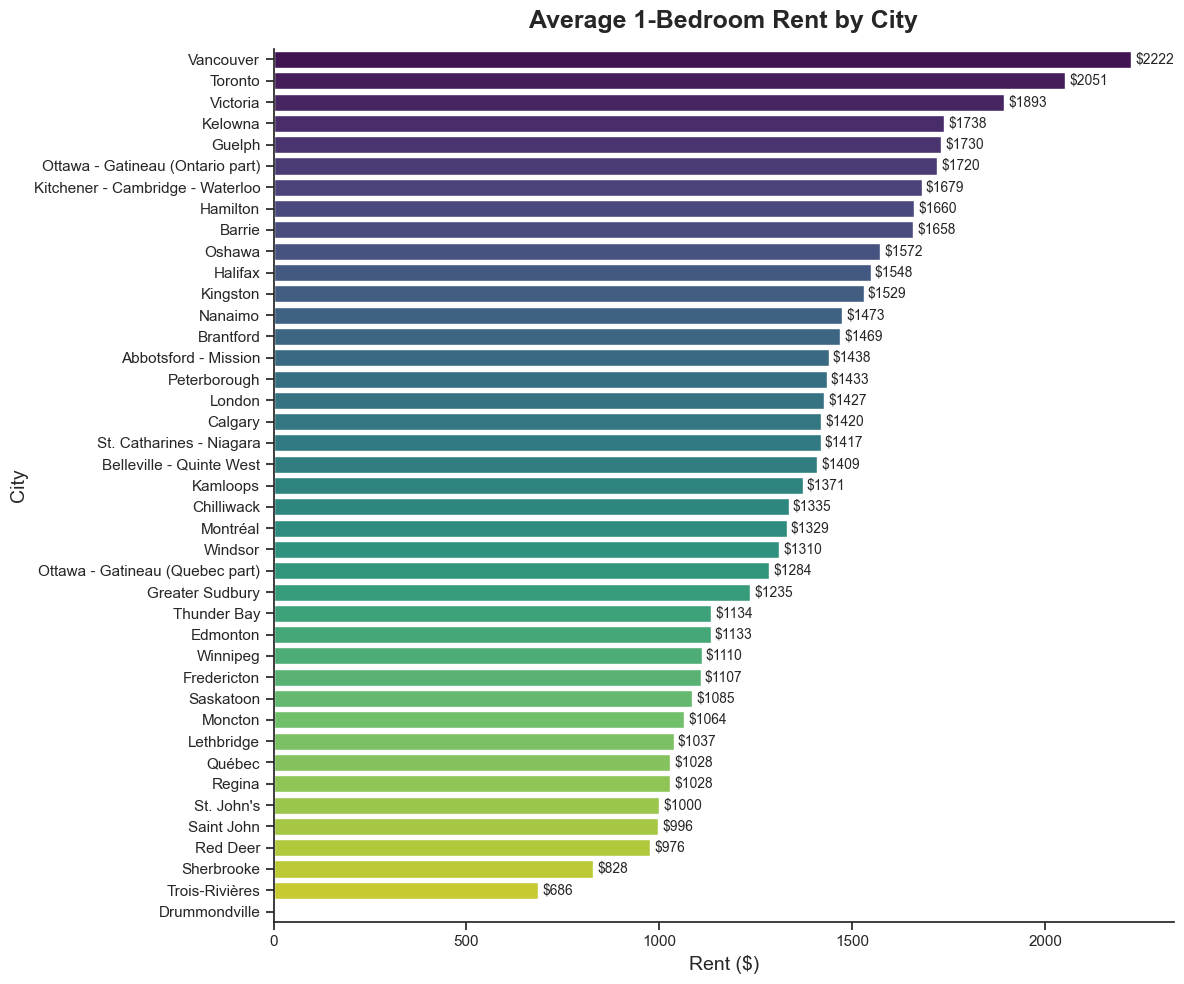

In [152]:
#import the libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Loadinf the dataset
df = pd.read_csv("cleaned_Cost_of_living_data.csv")
df.head()

#Average by rent by city
sns.set_theme(style="ticks")

# Sort cities by 1-bedroom rent
plot_df = Rental_pivot.groupby("City")["1_Bedroom_Rent"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 10))

ax = sns.barplot(
    data=plot_df,
    y="City",
    x="1_Bedroom_Rent",
    palette="viridis"
)

# Add rent labels to each bar
for i, row in plot_df.iterrows():
    if pd.notna(row["1_Bedroom_Rent"]):
        ax.text(
            row["1_Bedroom_Rent"] + 10,
            i,
            f"${int(row['1_Bedroom_Rent'])}",
            va='center',
            fontsize=10
        )

sns.despine(left=False, right=True, top=True, bottom=False)

plt.title("Average 1-Bedroom Rent by City", fontsize=18, weight="bold", pad=15)
plt.xlabel("Rent ($)", fontsize=14)
plt.ylabel("City", fontsize=14)

plt.tight_layout()
plt.show()

## Average Rent for 1 bedroom vs 2 bedroom by City

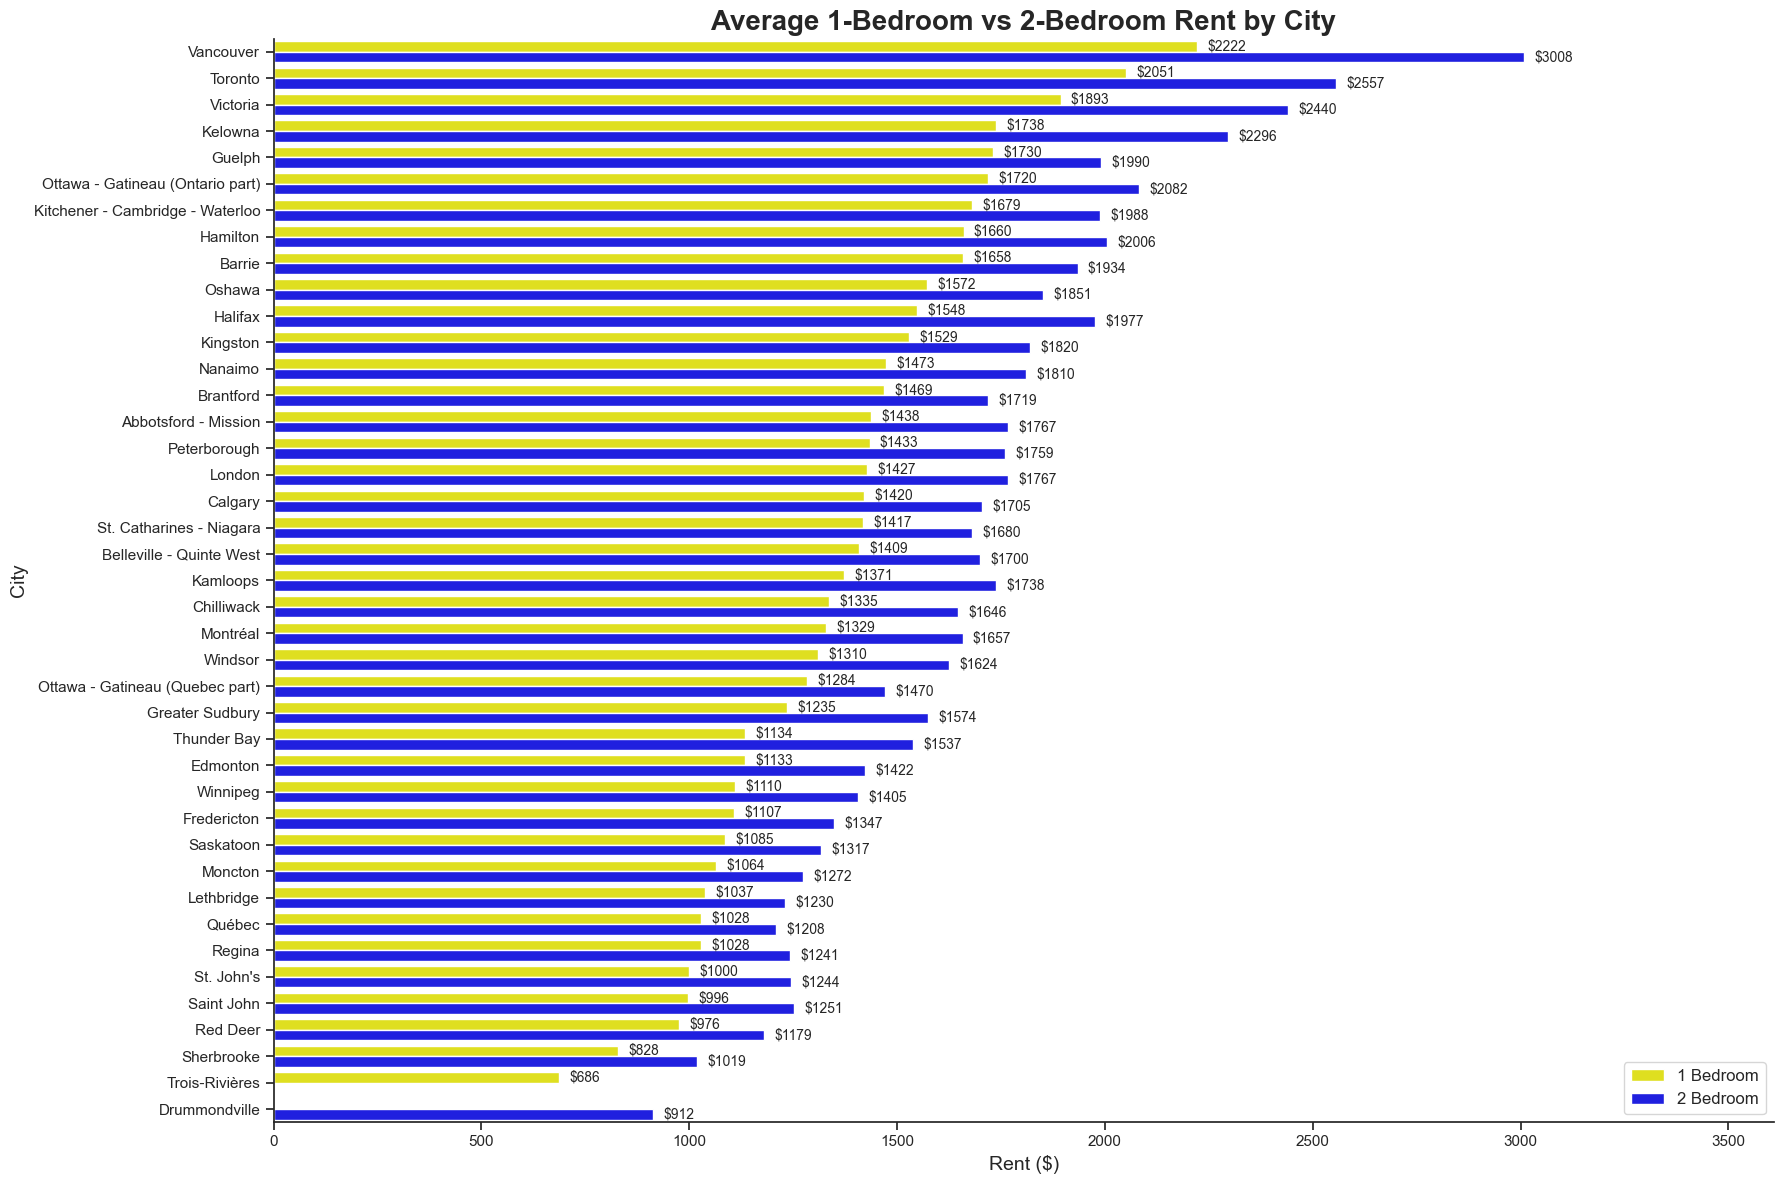

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

# Wider figure so bars have space
plt.figure(figsize=(18, 12))

# Sort cities by 1-bedroom rent
city_order = avg_rent.sort_values("1_Bedroom_Rent", ascending=False)["City"]

ax = sns.barplot(
    data=long_rent,
    y="City",
    x="Rent",
    hue="Bedroom_type",
    order=city_order,
    palette=["#0045a5", "#00c698"]

# Keep axis lines but remove clutter
sns.despine(top=True, right=True, left=False, bottom=False)

# Add right padding for labels
plt.xlim(0, long_rent["Rent"].max() * 1.20)

# Add labels on bars
for bar in ax.patches:
    width = bar.get_width()
    if width > 0:  # ignore zero-width bars
        y = bar.get_y() + bar.get_height() / 2
        ax.text(
            width + 25,
            y,
            f"${int(width)}",
            va='center',
            fontsize=10
        )

plt.title("Average 1-Bedroom vs 2-Bedroom Rent by City", fontsize=20, weight="bold")
plt.xlabel("Rent ($)", fontsize=14)
plt.ylabel("City", fontsize=14)

plt.legend(title="", fontsize=12, loc="lower right")

plt.tight_layout()
plt.show()
